In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('IBM_HR_Attrition_Enhanced.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,TenureGroup,MonthlyIncomeBracket,OverallSatisfactionIndex
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,35-44,Established (6-10 yrs),High,2.00
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,45-54,Established (6-10 yrs),High,3.00
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,35-44,New (0-2 yrs),Low,3.00
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,25-34,Established (6-10 yrs),Low,3.25
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,25-34,New (0-2 yrs),Medium,2.50


In [2]:
total_employees = len(df)
attrition_count = df[df['Attrition'] == 'Yes'].shape[0]
attrition_rate = (attrition_count / total_employees) * 100

print(f"Total Employees: {total_employees}")
print(f"Attrition Count: {attrition_count}")
print(f"Attrition Rate: {attrition_rate:.2f}%")

Total Employees: 1470
Attrition Count: 237
Attrition Rate: 16.12%


In [3]:
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)
print(dept_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [4]:
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)
print(overtime_attrition)

OverTime
Yes    30.528846
No     10.436433
Name: Attrition, dtype: float64


In [5]:
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

numeric_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany',
                 'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
                 'TotalWorkingYears', 'YearsSinceLastPromotion']

correlation = df[numeric_cols + ['Attrition_Flag']].corr()['Attrition_Flag'].sort_values()
print(correlation)

TotalWorkingYears         -0.171063
MonthlyIncome             -0.159840
Age                       -0.159205
YearsAtCompany            -0.134392
JobSatisfaction           -0.103481
EnvironmentSatisfaction   -0.103369
WorkLifeBalance           -0.063939
YearsSinceLastPromotion   -0.033019
DistanceFromHome           0.077924
Attrition_Flag             1.000000
Name: Attrition_Flag, dtype: float64


In [6]:
comparison = df.groupby('Attrition')[['MonthlyIncome', 'YearsAtCompany', 'Age', 'TotalWorkingYears']].mean()
print(comparison)

           MonthlyIncome  YearsAtCompany        Age  TotalWorkingYears
Attrition                                                             
No           6832.739659        7.369019  37.561233          11.862936
Yes          4787.092827        5.130802  33.607595           8.244726


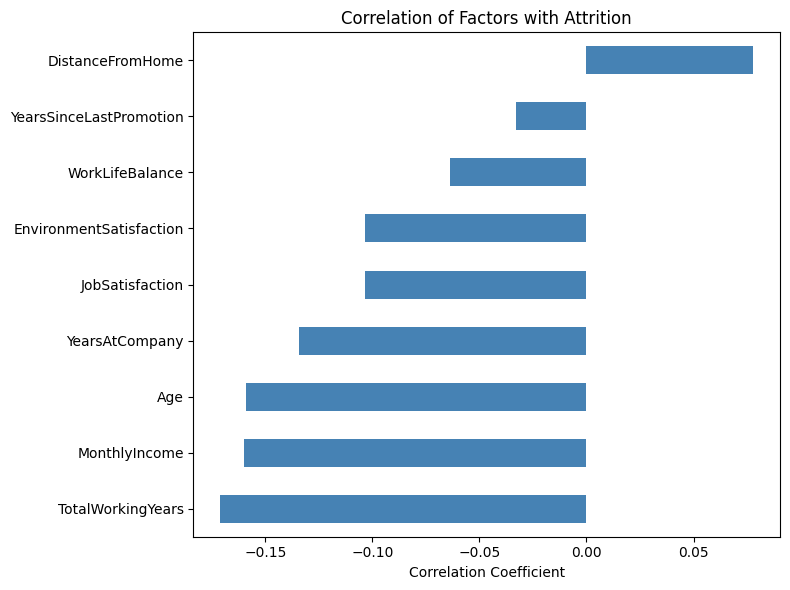

In [7]:
plt.figure(figsize=(8,6))
correlation.drop('Attrition_Flag').plot(kind='barh', color='steelblue')
plt.title('Correlation of Factors with Attrition')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

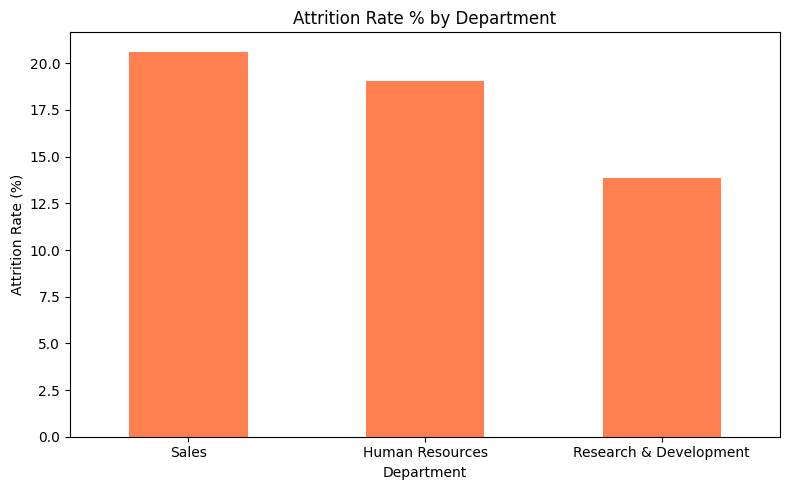

In [8]:
plt.figure(figsize=(8,5))
dept_attrition.plot(kind='bar', color='coral')
plt.title('Attrition Rate % by Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()